# 🧹 Notebook 02: Data Cleaning & Feature Extraction
**โครงการ**: Used Car Analytics (ETL Pipeline & Data Warehouse)

สมุดบันทึกนี้สาธิตกระบวนการ **Data Cleaning & Feature Extraction** สำหรับข้อมูลดิบทั้ง 3 แหล่งข้อมูล:
1. **Kaidee Auto (JSON):** สกัดราคา เลขไมล์ และแก้ปัญหาตำแหน่งจังหวัดหายไป
2. **One2car (Multi-CSV):** กรองราคาหลอก (เช่น ราคา 100 บาท) และสกัดคุณลักษณะ `body_type` / `fuel_type` ด้วย Regex
3. **US Used Car Sales (CSV):** กรองข้อมูล Typo (ปี 20130000 และเลขไมล์ติดลบ/ผิดปกติ)

---

### 1. Setup Environment & Import Modules

In [1]:
import sys
import os
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup path to import src modules
base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.exists(os.path.join(base_dir, "01_Raw_Data")):
    base_dir = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if not os.path.exists(os.path.join(base_dir, "01_Raw_Data")):
    base_dir = os.path.abspath(".")

sys.path.append(os.path.join(base_dir, "02_ETL"))
from src.extract import extract_raw_data
from src.clean import clean_kaidee_data, clean_one2car_data, clean_us_sales_data

sns.set_theme(style="whitegrid")
print("✅ Setup environment & imported ETL modules successfully!")

✅ Setup environment & imported ETL modules successfully!


### 2. Extract Raw Data & Apply Data Cleaning Pipeline

In [2]:
# 1. Extract
df_kaidee_raw, df_one2car_raw, df_us_raw = extract_raw_data(base_dir)

# 2. Clean
df_kaidee_clean = clean_kaidee_data(df_kaidee_raw)
df_one2car_clean = clean_one2car_data(df_one2car_raw)
df_us_clean = clean_us_sales_data(df_us_raw)

# Summary Table
summary_data = {
    "Data Source": ["Kaidee Auto (JSON)", "One2car (Multi-CSV)", "US Sales (CSV)"],
    "Raw Rows": [len(df_kaidee_raw), len(df_one2car_raw), len(df_us_raw)],
    "Cleaned Rows": [len(df_kaidee_clean), len(df_one2car_clean), len(df_us_clean)],
    "Dropped Rows": [len(df_kaidee_raw)-len(df_kaidee_clean), len(df_one2car_raw)-len(df_one2car_clean), len(df_us_raw)-len(df_us_clean)],
    "Retention Rate (%)": [
        len(df_kaidee_clean)/len(df_kaidee_raw)*100,
        len(df_one2car_clean)/len(df_one2car_raw)*100,
        len(df_us_clean)/len(df_us_raw)*100
    ]
}
df_summary = pd.DataFrame(summary_data)
print("=== Data Cleaning Summary Table ===")
print(df_summary.to_string(index=False))

[Extract] Ingesting Data Source 1: Kaidee Auto JSON from /home/naeiger/data-min/project-group/01_Raw_Data/kaidee/kaidee_cars_detail.json...
[Extract] Ingesting & Standardizing Data Source 2: 3 raw One2Car scraped period files...
[Extract] Ingesting Data Source 3: US Sales raw data from /home/naeiger/data-min/project-group/01_Raw_Data/us-usecar/used_car_sales.csv...


[Extract Completed] Kaidee Auto JSON: 1,443 rows | One2car Multi-file: 4,190 rows | US Sales: 122,144 rows
[Clean] Cleaning Kaidee Auto JSON dataset...


[Clean Completed] Kaidee Auto cleaned: 1,395 valid rows (Dropped 48 duplicate/invalid rows)
[Clean] Cleaning One2car dataset & extracting BodyType/FuelType features...


[Clean Completed] One2car cleaned: 3,870 valid rows (Dropped 320 duplicate/invalid/trap rows)
[Clean] Cleaning US Sales dataset & filtering typos...
[Clean Completed] US Sales cleaned: 116,659 valid rows (Dropped 5485 typo/duplicate rows)
=== Data Cleaning Summary Table ===
        Data Source  Raw Rows  Cleaned Rows  Dropped Rows  Retention Rate (%)
 Kaidee Auto (JSON)      1443          1395            48           96.673597
One2car (Multi-CSV)      4190          3870           320           92.362768
     US Sales (CSV)    122144        116659          5485           95.509399


### 3. Visual Audit: Before vs After Cleaning

/tmp/ipykernel_34934/780996187.py:15: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/naeiger/data-min/project-group/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


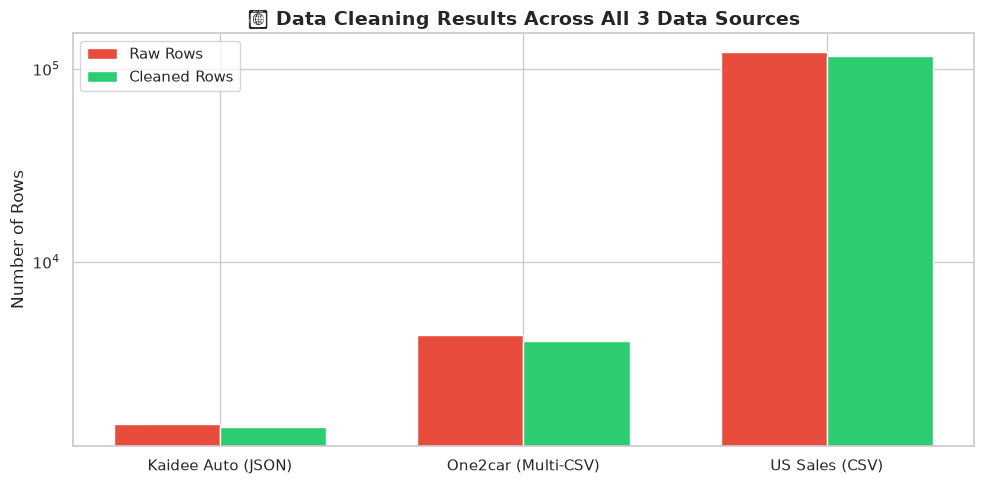

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_summary["Data Source"]))
width = 0.35

rects1 = ax.bar(x - width/2, df_summary["Raw Rows"], width, label="Raw Rows", color="#e74c3c")
rects2 = ax.bar(x + width/2, df_summary["Cleaned Rows"], width, label="Cleaned Rows", color="#2ecc71")

ax.set_ylabel("Number of Rows")
ax.set_title("📊 Data Cleaning Results Across All 3 Data Sources", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_summary["Data Source"])
ax.legend()
ax.set_yscale("log")  # Log scale due to US Sales dataset size

plt.tight_layout()
plt.show()

### 4. Extracted Features Distribution (BodyType & FuelType)

/tmp/ipykernel_34934/3242377438.py:11: UserWarning: Glyph 128664 (\N{ONCOMING AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_34934/3242377438.py:11: UserWarning: Glyph 9981 (\N{FUEL PUMP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/home/naeiger/data-min/project-group/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128664 (\N{ONCOMING AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/naeiger/data-min/project-group/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9981 (\N{FUEL PUMP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


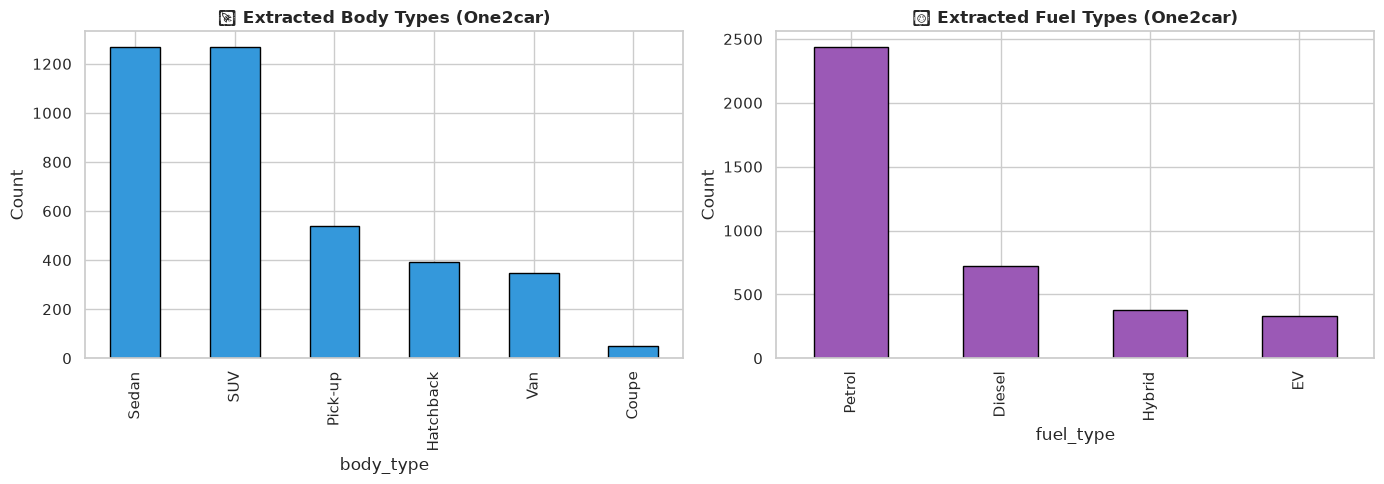

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_one2car_clean["body_type"].value_counts().plot(kind="bar", ax=axes[0], color="#3498db", edgecolor="black")
axes[0].set_title("🚘 Extracted Body Types (One2car)", fontweight="bold")
axes[0].set_ylabel("Count")

df_one2car_clean["fuel_type"].value_counts().plot(kind="bar", ax=axes[1], color="#9b59b6", edgecolor="black")
axes[1].set_title("⛽ Extracted Fuel Types (One2car)", fontweight="bold")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()